In [1]:
import random
import logging
import numpy as np
import os
import re
import nibabel as nib
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import copy
from tqdm.auto import tqdm
import itertools
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import pickle
from osl_dynamics.data import Data
from osl_dynamics.data import processing
from osl_dynamics.models.hmm import Config
from osl_dynamics.models.hmm import Model
from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes

In [2]:
random.seed(42)
np.random.seed(42)

# Prepare Data

In [3]:
# Silence unnecessary messages
_logger = logging.getLogger("osl-dynamics")
_logger.setLevel(logging.CRITICAL + 1)

In [4]:
# # Load data
# data_path = '../../CIMT_data/no_wm/stim data timepoint by roi and z scored along roi dimension no white matter' # task fMRI
# # data_path = '/Users/fei/Downloads/stim data time series csv organized not z scored no white matter'
# X = []
# y = []

# for subj in sorted(os.listdir(data_path)):
#     if subj != '.DS_Store':
#         tc = glob.glob(f'{data_path}/*.csv')[0]
#         X.append(np.loadtxt(tc, delimiter=','))
#         y.append(subj[:12])

# X = np.array(X) # X.shape = (subjects, timepoints, ROIs)
# y = np.array(y)
# print(X.shape)
# print(y.shape)

In [5]:
data_path = '../../CIMT_data/no_wm/LLstim_ICA_19c'
with open(data_path + '/' + data_path.split('/')[-1] + 'SelectedDataFolders.txt', 'r') as f:
    subj_order = f.readlines()

bad_ICs = [18, 19] 
X = []
y = []
i = 0
for tc in sorted(os.listdir(data_path)):
    if re.search(r"[0-9]_timecourses_ica_s1_.nii$", tc):
        # X.append(np.loadtxt(os.path.join(data_path, tc), delimiter=','))
        nii = nib.load(os.path.join(data_path, tc))
        X.append(nii.get_fdata())
        y.append(subj_order[i][-17:-5])
        i += 1

X = np.array(X) # X.shape = (subjects, timepoints, ROIs)
X = np.delete(X, obj=[IC - 1 for IC in bad_ICs], axis=2)
y = np.array(y)
print(X.shape)
print(y.shape)

(114, 250, 17)
(114,)


In [6]:
print(X[0].shape)
print(np.prod(X[0].shape)) # n_samples = timepoints * subjects

(250, 17)
4250


In [7]:
np.unique(y)

array(['CCI_CIMT_07d', 'CCI_CIMT_21d', 'CCI_CIMT_49d', 'CCI_none_07d',
       'CCI_none_21d', 'CCI_none_49d', 'SHM_none_07d', 'SHM_none_21d',
       'SHM_none_49d'], dtype='<U12')

In [8]:
full_data = Data(X)
print(full_data)

Loading files:   0%|          | 0/114 [00:00<?, ?it/s]

Data
 id: 13147272544
 n_sessions: 114
 n_samples: 28500
 n_channels: 17


In [9]:
full_data.prepare({
    # "pca": {"n_pca_components": n_pca_components},
    "standardize": {},
})

Standardize:   0%|          | 0/114 [00:00<?, ?it/s]

# Create Folds

In [10]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits)

In [11]:
split_plan = {
    'outer_train': [],
    'outer_test': [],
    'inner_train': [],
    'inner_val': [],
}

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"Fold {i + 1}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    outer_train, outer_test, y_train, y_test = X[train_index,], X[test_index,], y[train_index,], y[test_index,]
    
    # Check for even splits within groups  
    print(np.sum(y_test == "CCI_CIMT_07d") / np.sum(y == "CCI_CIMT_07d"))
    print(np.sum(y_test == "CCI_CIMT_21d") / np.sum(y == "CCI_CIMT_21d"))
    print(np.sum(y_test == "CCI_CIMT_49d") / np.sum(y == "CCI_CIMT_49d"))
    print(np.sum(y_test == "CCI_none_07d") / np.sum(y == "CCI_none_07d"))
    print(np.sum(y_test == "CCI_none_21d") / np.sum(y == "CCI_none_21d"))
    print(np.sum(y_test == "CCI_none_49d") / np.sum(y == "CCI_none_49d"))
    print(np.sum(y_test == "SHM_none_07d") / np.sum(y == "SHM_none_07d"))
    print(np.sum(y_test == "SHM_none_21d") / np.sum(y == "SHM_none_21d"))
    print(np.sum(y_test == "SHM_none_49d") / np.sum(y == "SHM_none_49d"))
    
    inner_train, inner_val, y_inner_train, y_inner_val = train_test_split(outer_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    
    outer_train = Data(outer_train)
    outer_test = Data(outer_test)
    inner_train = Data(inner_train)
    inner_val = Data(inner_val)
    
    outer_train.prepare({
        # "pca": {"n_pca_components": n_pca_components},
        "standardize": {},
    })
    outer_test.prepare({
        # "pca": {"pca_components": outer_train.pca_components},
        "standardize": {},
    })
    outer_test = outer_test.dataset(sequence_length=250, batch_size=outer_test.n_sessions) # ensure consistent evaluation across models of different sequence_length

    inner_train.prepare({
        # "pca": {"n_pca_components": n_pca_components},
        "standardize": {},
    })
    inner_val.prepare({
        # "pca": {"pca_components": inner_train.pca_components},
        "standardize": {},
    })

    split_plan['outer_train'].append(outer_train)
    split_plan['outer_test'].append(outer_test)
    split_plan['inner_train'].append(inner_train)
    split_plan['inner_val'].append(inner_val)

Fold 1:
  Train: index=[  3   4   5   6   7   8   9  10  11  12  13  14  18  19  20  21  22  23
  24  25  26  27  28  29  33  34  35  36  37  38  39  40  41  42  43  44
  48  49  50  51  52  53  54  55  56  57  58  59  63  64  65  66  67  68
  69  70  71  72  73  74  78  79  80  81  82  83  84  85  86  87  88  89
  92  93  94  95  96  97 100 101 102 103 104 105 107 108 109 110 111 112
 113]
  Test:  index=[  0   1   2  15  16  17  30  31  32  45  46  47  60  61  62  75  76  77
  90  91  98  99 106]
0.2
0.2
0.2
0.2
0.2
0.2
0.25
0.25
0.125


Loading files:   0%|          | 0/91 [00:00<?, ?it/s]

Loading files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

Standardize:   0%|          | 0/92 [00:00<?, ?it/s]

Standardize:   0%|          | 0/22 [00:00<?, ?it/s]

Standardize:   0%|          | 0/73 [00:00<?, ?it/s]

Standardize:   0%|          | 0/19 [00:00<?, ?it/s]

# HMM Training

In [12]:
def get_param_combinations(param_grid):
    combinations = itertools.product(*param_grid.values())
    return [dict(zip(param_grid.keys(), combination)) for combination in combinations]

In [13]:
full_data.recommend_model_config()

Recommendation:
  config = Config(
      ...
      sequence_length=200,
      batch_size=28,
      learning_rate=0.01,
      n_epochs=20,
  )
Total number of sequences: 114
Total number of batches/parameter updates: 5


In [14]:
hyperparam_grid_ICA_no_TDE = {
    'sequence_length': [250], # .recommend_model_config() recommends 200, so increasing slightly to 250 for clean division of 250
    'batch_size': [28],
    'learning_rate': [0.01], 
    'n_epochs': [20, 30, 40, 50, 60, 70, 80, 90, 100], # added more options to check for possible further improvement past 20 epochs
}

## k-fold CV to Determine Optimal Hyperparameters for Each Number of States

In [15]:
model_eval_log = {}

In [16]:
pkl_suffix = "ICA_no_TDE"

In [17]:
if os.path.exists(f'grid_search/model_eval_log_{pkl_suffix}.pkl'):
    with open(f'grid_search/model_eval_log_{pkl_suffix}.pkl', 'rb') as f:
        model_eval_log = pickle.load(f)
else:
    os.mkdir('grid_search')

sorted(model_eval_log.keys())

[6, 7, 8, 9, 10, 11, 12, 13, 14]

In [30]:
# CV to determine optimal hyperparameters for each number of states 
min_n_states = 10 # must be >= 2
max_n_states = 10
hyperparam_grid = hyperparam_grid_ICA_no_TDE
for num_states in range(min_n_states, max_n_states + 1):
    print(f"\nGrid searching with {num_states} states...")
    if num_states not in model_eval_log:
        model_eval_log[num_states] = {
            'hyperparams': [], # {hyperparams}
            'histories': [], # [history object from best run for each fold]
            'test_free_energies': [], # [float]
        }

    i = 1
    for hyperparams in get_param_combinations(hyperparam_grid):
        print(f"Param set {i}: {hyperparams}")
        histories = []
        test_free_energies = []
        for f in range(n_splits):
            print(f"\nFold {f + 1}...")
            outer_test, inner_train, inner_val = split_plan['outer_test'][f], split_plan['inner_train'][f], split_plan['inner_val'][f]
            config = Config(
                n_states=num_states,
                n_channels=inner_train.n_channels,
                sequence_length=hyperparams['sequence_length'],
                learn_means=False,
                learn_covariances=True,
                batch_size=hyperparams['batch_size'],
                learning_rate=hyperparams['learning_rate'],
                n_epochs=hyperparams['n_epochs'],
            )
            
            model = Model(config)
            model.random_state_time_course_initialization(inner_train, verbose=0) # n_epochs defaults to 1 and n_init defaults to 3
            callback = EarlyStopping(monitor='val_loss', patience=5, verbose=0) # we don't need restore_best_weights=True because we aren't saving the models
            history = model.fit(
                inner_train,
                validation_data=inner_val.dataset(
                    sequence_length=hyperparams['sequence_length'],
                    batch_size=hyperparams['batch_size'],
                ),
                verbose=0,
                callbacks=[callback],
            )
                
            histories.append(history)
                    
            test_free_energy = model.free_energy(outer_test)
            test_free_energies.append(test_free_energy)

        model_eval_log[num_states]['hyperparams'].append(hyperparams)
        model_eval_log[num_states]['histories'].append(histories)
        model_eval_log[num_states]['test_free_energies'].append(test_free_energies) # can take the mean across folds later

        i += 1

    with open(f'grid_search/model_eval_log_{pkl_suffix}.pkl', 'wb') as f:
        pickle.dump(model_eval_log, f)


Grid searching with 10 states...
Param set 1: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 110}

Fold 1...


Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 2...


Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 3...


...

Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 4...


Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 5...


Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
sorted_states = sorted(model_eval_log.keys())
sorted_states

[6, 7, 8, 9, 10, 11, 12, 13, 14]

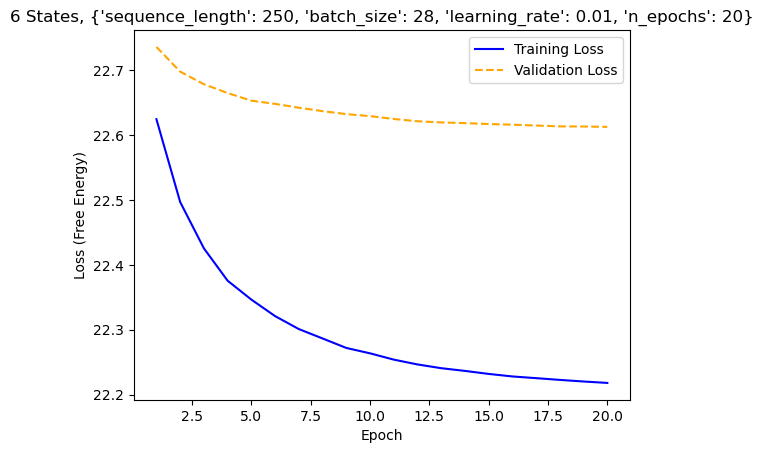

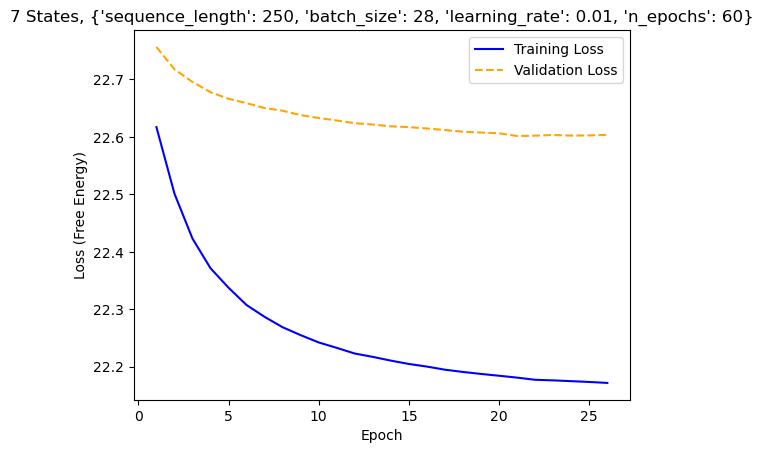

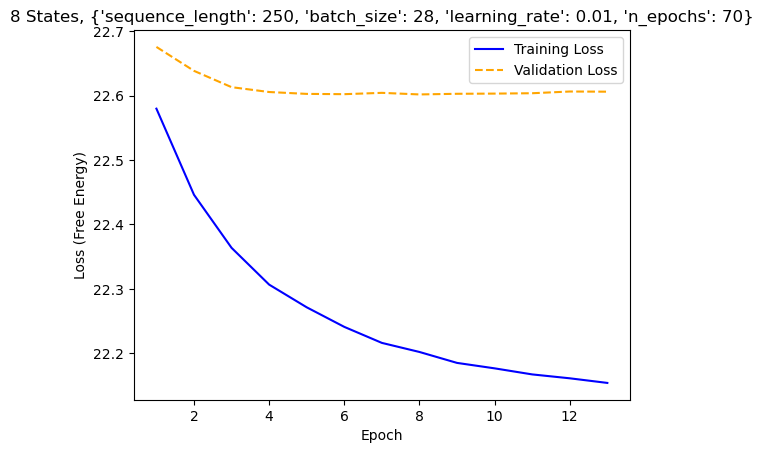

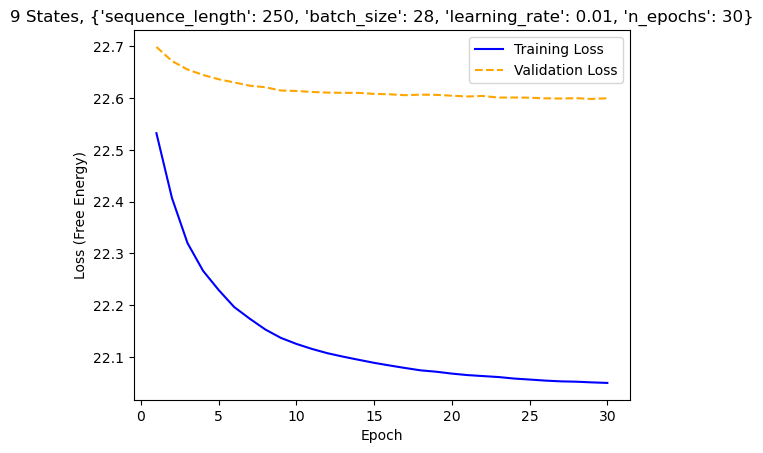

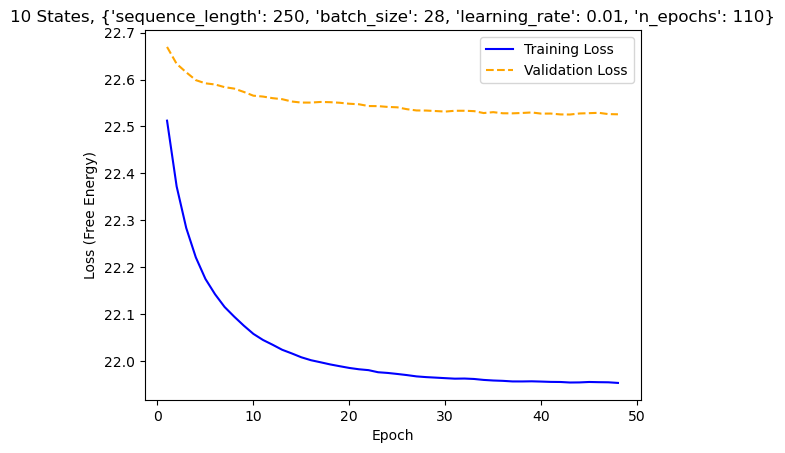

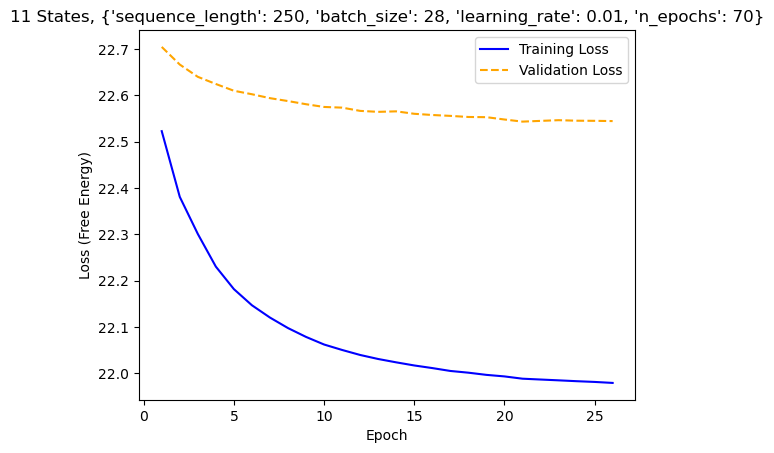

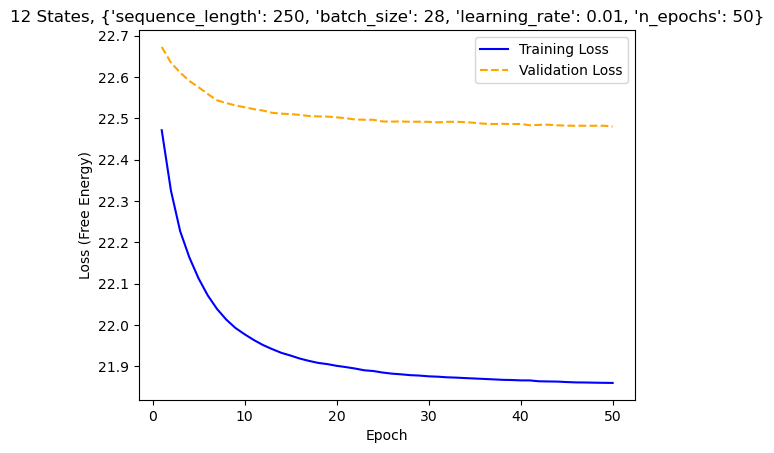

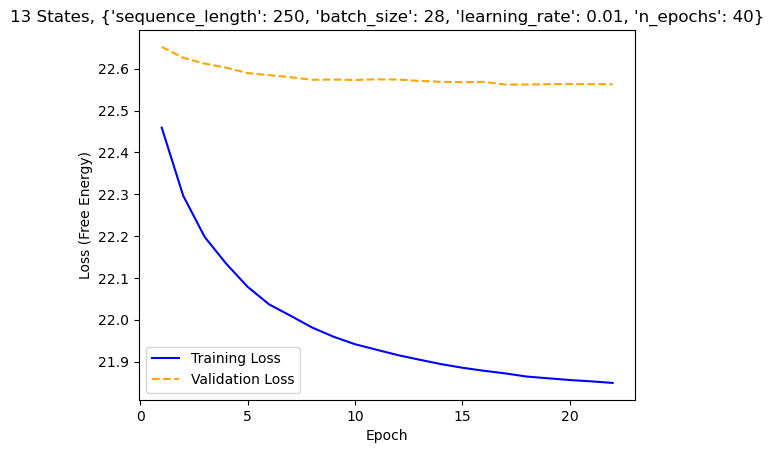

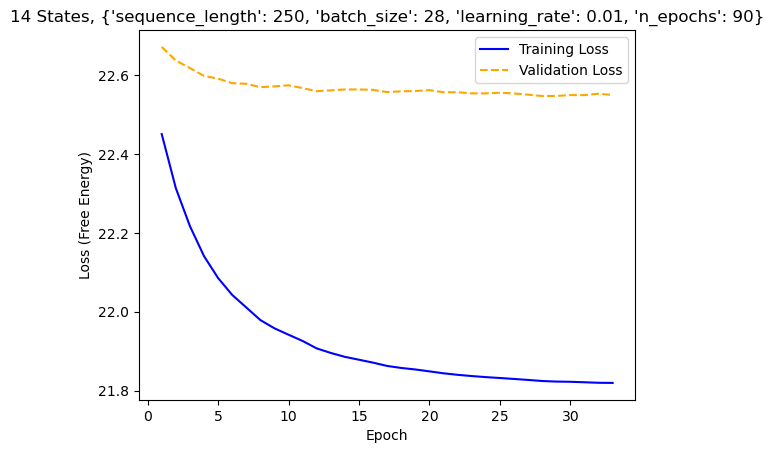

In [20]:
# Sanity check
f_idx = 0
for num_states in sorted_states:
    example = model_eval_log[num_states]['histories'][np.argmax(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]
    fig, ax = plt.subplots(1, 1)
    x = range(1, len(example[f_idx]['loss']) + 1)
    ax.plot(x, example[f_idx]['loss'], label="Training Loss", color='blue', linestyle='-')
    ax.plot(x, example[f_idx]['val_loss'], label="Validation Loss", color='orange', linestyle='--')

    ax.set_title(f"{num_states} States, " + str(model_eval_log[num_states]['hyperparams'][np.argmax(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (Free Energy)")
    ax.legend()
    plt.show()

In [21]:
for num_states in sorted_states:
    print(f"Best params for {num_states} states: {model_eval_log[num_states]['hyperparams'][np.argmax(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]}")

Best params for 6 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 20}
Best params for 7 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 60}
Best params for 8 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 70}
Best params for 9 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 30}
Best params for 10 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 110}
Best params for 11 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 70}
Best params for 12 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 50}
Best params for 13 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 40}
Best params for 14 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.01, 'n_epochs': 90}


## Compute Model Evaluation Metrics on the Full Dataset for Each Number of States

In [22]:
num_realizations = 10
results_path = f'results/{pkl_suffix}'
os.makedirs(results_path, exist_ok=True) # don't worry, os.makedirs() never replaces a directory (or parent directory) if it already exists

In [ ]:
# Compute full-dataset evaluation metrics
for num_states in sorted_states:
    print(f"Fitting model with {num_states} states...")
    model_eval_log[num_states]['realizations'] = []
    realizations = [] # contains model object from each realization. Models can't be pickled, so we will pick the best realization and save the corresponding model object separately
    model_eval_log[num_states]['free_energy'] = []
    model_eval_log[num_states]['full_LL'] = []
    model_eval_log[num_states]['BIC'] = []
    model_eval_log[num_states]['MMDL'] = []
    # model_eval_log[n]['ICL'] = []
    for r in range(num_realizations): # account for variability in .random_state_time_course_initialization(), then average later
        print(f"Realization {r + 1}:")
        model_eval_log[num_states]['realizations'].append({})
        best_hyperparams = model_eval_log[num_states]['hyperparams'][np.argmax(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]
        config = Config(
            n_states=num_states,
            n_channels=full_data.n_channels,
            sequence_length=best_hyperparams['sequence_length'],
            learn_means=False,
            learn_covariances=True,
            batch_size=best_hyperparams['batch_size'],
            learning_rate=best_hyperparams['learning_rate'],
            n_epochs=best_hyperparams['n_epochs'],
            loss_calc='mean', # to get the average per-timepoint log likelihood when computing test evidence
        )

        model = Model(config)
        model.random_state_time_course_initialization(full_data, verbose=0)
        history = model.fit(full_data, verbose=0)
        realizations.append(model)
        
        free_energy = model.free_energy(full_data) # note that .free_energy() returns the free energy averaged over batches
        model_eval_log[num_states]['free_energy'].append(free_energy)

        _, covs = model.get_means_covariances() # learn_means=False so means will be zero 
        model_eval_log[num_states]['realizations'][r]['covs'] = covs
    
        off_diags = []
        dofs = [] # degrees of freedom of inverse covariance matrices (precision matrices), used to compute MMDL
        for cov in covs:
            ut = np.triu(cov, k=1) # upper triange, excluding main diagonal
            off_diag = ut[ut != 0]
            off_diags.append(off_diag)

            precision_matrix = np.linalg.inv(cov)
            precision_matrix_ut = np.triu(precision_matrix) # upper triangle, incuding main diagonal
            dofs.append(np.sum(precision_matrix_ut != 0)) # "Df(k) is the number of non-zeroes in the precision matrix"
    
        model_eval_log[num_states]['realizations'][r]['off_diags'] = np.array(off_diags).T
        
        mean_per_timepoint_LL = model.evidence(full_data)
        full_LL = mean_per_timepoint_LL * full_data.n_samples
        model_eval_log[num_states]['full_LL'].append(full_LL)
    
        # Compute Bayesian Information Criterion (BIC)
        d = full_data.n_channels
        k = (num_states - 1) + num_states * (num_states - 1) + num_states * (d + (d * (d + 1)) / 2) # number of estimated parameters
        BIC = k * np.log(full_data.n_samples) - 2 * full_LL
        model_eval_log[num_states]['BIC'].append(BIC)

        # Compute Mixture Minimum Description Length (MMDL) 
        alpha = np.array(model.get_alpha(full_data)) # state probability time courses for each subject (subjects x timepoints x num_states)
        third_term = np.sum([np.log(full_data.n_samples * np.sum(alpha[:, :, state_num])) * dofs[state_num] for state_num in range(num_states)]) / 2
        MMDL = -full_LL + np.log(full_data.n_samples) * num_states * (num_states - 1) / 2 + third_term
        model_eval_log[num_states]['MMDL'].append(MMDL)
    
        # # Compute ICL (integrated completed likelihood)
        # pred_data = copy.deepcopy(full_data)
        # pred_data = pred_data.dataset(sequence_length=model.config.sequence_length, batch_size=full_data.n_sessions)
        # entropies = []
        # for batch in tqdm(pred_data, desc="Computing posterior entropy..."):
        #     pred = model.predict(batch, verbose=0)
        #     entropy = model.get_posterior_entropy(pred['gamma'], pred['xi']) 
        #     entropies.append(entropy)
            
        # posterior_entropy = np.mean(entropies) * full_data.n_samples
        # ICL = BIC + 2 * posterior_entropy # add because .get_posterior_entropy() technically returns the negative posterior entropy
        # model_eval_log[n]['ICL'].append(ICL)

    model_dir = f'{results_path}/{num_states}_states'
    os.makedirs(model_dir, exist_ok=True)
    best_realization_path = f'{model_dir}/{num_states}_states_model'
    realizations[np.argmin(model_eval_log[num_states]['MMDL'])].save(best_realization_path) # save model object with lowest MMDL
    model_eval_log[num_states]['best_realization_path'] = best_realization_path
    with open(f'grid_search/model_eval_log_{pkl_suffix}.pkl', 'wb') as f:
        pickle.dump(model_eval_log, f)

Fitting model with 6 states...
Realization 1:


2025-11-18 16:35:32.038923: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-18 16:35:33.887255: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Getting free energy:   0%|          | 0/5 [00:00<?, ?it/s]

2025-11-18 16:35:41.052116: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Getting evidence:   0%|          | 0/5 [00:00<?, ?it/s]

...

Realization 3:


Getting free energy:   0%|          | 0/5 [00:00<?, ?it/s]

Getting evidence:   0%|          | 0/5 [00:00<?, ?it/s]

Getting alpha:   0%|          | 0/114 [00:00<?, ?it/s]

Realization 4:


In [ ]:
metrics = ['free_energy', 'full_LL', 'BIC', 'MMDL']
for metric in metrics:
    one_se_rule = {}
    
    for key, value in model_eval_log.items():
        one_se_rule[key] = {
            'mean': np.mean(value[metric]),
            'se': np.std(value[metric], ddof=1) / np.sqrt(num_realizations),
        }

    sorted_by_mean = sorted(list(one_se_rule.items()), key=lambda x: x[1]['mean'])
    
    fig, ax = plt.subplots(1, 1)
    num_states_list = [x[0] for x in sorted_by_mean]
    means = [x[1]['mean'] for x in sorted_by_mean]
    ax.scatter(num_states_list, means)
    if metric == 'full_LL':
        ax.axhline(y=sorted_by_mean[-1][1]['mean'] - sorted_by_mean[-1][1]['se'], color='r', linestyle='--')
        ax.set_title("Mean Log-Likelihood vs. Number of States")
        ax.set_xlabel("Number of States")
        ax.set_ylabel("Mean Log-Likelihood")
    else:
        ax.axhline(y=sorted_by_mean[0][1]['mean'] + sorted_by_mean[0][1]['se'], color='r', linestyle='--')
        ax.set_title(f"Mean {metric} vs. Number of States")
        ax.set_xlabel("Number of States")
        ax.set_ylabel(f"Mean {metric}")
    plt.show()

    print(f"num_states: {metric}")
    for num_states in num_states_list:
        print(f"{num_states}: {np.mean(model_eval_log[num_states][metric])}")

In [ ]:
def realization_corr(r1, r2):
    r1_stan = (r1 - np.mean(r1, axis=0, keepdims=True)) / np.std(r1, axis=0, keepdims=True)
    r2_stan = (r2 - np.mean(r2, axis=0, keepdims=True)) / np.std(r2, axis=0, keepdims=True)

    return r1_stan.T @ r2_stan / (r1_stan.shape[0] - 1)

In [ ]:
for num_states in sorted_states:
    CRCM = np.zeros(shape=(num_states * num_realizations, num_states * num_realizations))
    for i in range(num_realizations):
        for j in range(num_realizations):
            if i != j:
                CRCM[i * num_states:(i * num_states) + num_states, j * num_states:(j * num_states) + num_states] = abs(realization_corr(
                    model_eval_log[num_states]['realizations'][i]['off_diags'], 
                    model_eval_log[num_states]['realizations'][j]['off_diags']
                ))

    state_groups = [] # [(realization number, state number), ...] using 1-based indexing for realization and state numbers for interpretability
    while np.max(CRCM) > 0:
        state_groups.append([])
        m, n = np.unravel_index(np.argmax(CRCM), shape=CRCM.shape)
        state_groups[-1].append((int(m // num_states + 1), int(m % num_states + 1)))
        state_groups[-1].append((int(n // num_states + 1), int(n % num_states + 1)))
        for i in range(num_realizations):
            if i != m // num_states and i != n // num_states:
                p_i = i * num_states + np.argmax(CRCM[m, i * num_states:(i * num_states) + num_states])
                q_i = i * num_states + np.argmax(CRCM[i * num_states:(i * num_states) + num_states, n])
                if p_i == q_i or CRCM[m, p_i] > CRCM[q_i, n]:
                    state_groups[-1].append((i + 1, int(p_i % num_states + 1)))
                    CRCM[:, p_i] = 0
                    CRCM[p_i, :] = 0
                else:
                    state_groups[-1].append((i + 1, int(q_i % num_states + 1)))
                    CRCM[q_i, :] = 0
                    CRCM[:, q_i] = 0
    
        CRCM[m, :] = 0
        CRCM[:, m] = 0
        CRCM[:, n] = 0
        CRCM[n, :] = 0

    within_group_avg_corrs = []
    for g in range(len(state_groups)):
        off_diags = []
        within_group_corrs = []
        for r, s in sorted(state_groups[g], key=lambda r: r[0]):
            off_diags.append(model_eval_log[num_states]['realizations'][r - 1]['off_diags'][:, s - 1]) # r and s use 1-based indexing, so must subtract 1
            
        for i in range(len(off_diags)):
            for j in range(i + 1, len(off_diags)):
                within_group_corrs.append(np.corrcoef(off_diags[i], off_diags[j]))
    
        within_group_avg_corr = np.mean(within_group_corrs)
        within_group_avg_corrs.append(within_group_avg_corr)

    idx_seq = []
    for i, corr in sorted(enumerate(within_group_avg_corrs), key=lambda x: x[1], reverse=True):
        idx_seq.append(i)

    # Reorder state_groups and within_group_avg_corrs in order of decreasing average between-realization correlation
    state_groups = [state_groups[i] for i in idx_seq]
    within_group_avg_corrs = [within_group_avg_corrs[i] for i in idx_seq]
    print(f"\nAligned States for n_states={num_states}:")
    for g in range(len(state_groups)):
        print(f"\nAligned State {g + 1}:")
        for r, s in sorted(state_groups[g], key=lambda r: r[0]):
            print(f"Realization {r}, state {s}")
    
        print(f"Average between-realization correlation: {within_group_avg_corrs[g]}")

    plt.bar(
        [str(i) for i in range(1, len(state_groups) + 1)],
        within_group_avg_corrs,
    )
    plt.axhline(y=0.8, color='r', linestyle='--') # stability threshold
    
    plt.title(f"Average Between-Realization Correlation of Aligned States (n_states={num_states})")
    plt.xlabel("Aligned State Number")
    plt.ylabel("Average Between-Realization Correlation")
    plt.show()